# ISAP EDA & Data Profiling Notebook

Notebook นี้เป็นหลักฐานการสำรวจข้อมูลจริงของทั้ง 2 datasets คือ OCSC และ CGD ก่อนนำไปออกแบบ data warehouse และ pipeline

หลักการใช้งาน:

- ใช้ notebook เพื่ออธิบาย EDA/profiling ให้อ่านตามง่าย
- ใช้ production-style code ใน `src/isap_pipeline/` สำหรับ pipeline จริง
- ใช้รายงานใน `docs/` เป็น final answer สำหรับส่งผู้ตรวจ


## tl;dr

- OCSC workbook มี 68 sheets และเป็น Excel แบบรายงาน มี cover/index, merged cells, formula cells, multi-row headers, subtotal/total rows และ wide tables หลายรูปแบบ
- CGD workbook มี 15 sheets โครงสร้างสม่ำเสมอกว่า แต่ยังมีหัวตาราง 2 ชั้น และต้องแยกความหมายระหว่าง `เบิกจ่าย` กับ `ใช้จ่าย`
- แนวทางที่เหมาะคือเก็บ raw cells ทุก sheet ก่อน แล้ว normalize เฉพาะ sheet/table ที่มี grain ชัดเจนเข้าสู่ staging/mart
- การเชื่อม OCSC กับ CGD ทำได้ระดับ demo ด้วย normalized Thai entity name แต่ production ควรมี master agency mapping


## 1. Setup

ส่วนนี้โหลด dependency และ helper function จาก package จริง เพื่อให้ notebook ไม่แยก logic ออกจาก pipeline


In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from openpyxl import load_workbook

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from isap_pipeline.dq import run_data_quality_checks
from isap_pipeline.excel_inspector import inspect_workbook
from isap_pipeline.extract_cgd import extract_cgd_workbook
from isap_pipeline.extract_ocsc import extract_ocsc_workbook
from isap_pipeline.metadata import SourceFileMetadata, sha256_file

warnings.filterwarnings("ignore", category=UserWarning, module=r"openpyxl\..*")
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 90)

OCSC_PATH = PROJECT_ROOT / "datasets" / "ocsc" / "thai-gov-manpower-2567.4.xlsx"
CGD_PATH = PROJECT_ROOT / "datasets" / "cgd" / "2026.07.03.xlsx"

assert OCSC_PATH.exists(), OCSC_PATH
assert CGD_PATH.exists(), CGD_PATH


## 2. Source Metadata

ตารางนี้ยืนยันตำแหน่งไฟล์, ขนาดไฟล์ และ SHA-256 hash สำหรับ lineage/idempotency


In [2]:
source_files = pd.DataFrame(
    [
        {
            "dataset": "ocsc_government_manpower",
            "path": str(OCSC_PATH.relative_to(PROJECT_ROOT)),
            "sha256": sha256_file(OCSC_PATH),
            "size_mb": round(OCSC_PATH.stat().st_size / 1024 / 1024, 2),
        },
        {
            "dataset": "cgd_budget_execution",
            "path": str(CGD_PATH.relative_to(PROJECT_ROOT)),
            "sha256": sha256_file(CGD_PATH),
            "size_mb": round(CGD_PATH.stat().st_size / 1024 / 1024, 2),
        },
    ]
)
source_files


,dataset,path,sha256,size_mb
0,ocsc_government_manpower,datasets\ocsc\thai-gov-manpower-2567.4.xlsx,fcb9ee5644ee235031a0e363e42dc8a207b72248e8d8ac770e6b4de9afad7f9b,3.08
1,cgd_budget_execution,datasets\cgd\2026.07.03.xlsx,309ad096e8e1372968346f994d2912faa5e89e96a3d389552ea9f9e3b2c58e95,1.09


## 3. Workbook Inventory

ใช้ `inspect_workbook()` เพื่อสรุป sheet count, cell count, merged cells, formula cells, blank rows และ guessed header row จากไฟล์จริง


In [3]:
ocsc_profile = inspect_workbook(OCSC_PATH)
cgd_profile = inspect_workbook(CGD_PATH)

ocsc_sheets = pd.DataFrame(ocsc_profile["sheets"])
cgd_sheets = pd.DataFrame(cgd_profile["sheets"])

workbook_summary = pd.DataFrame(
    [
        {
            "dataset": "OCSC",
            "sheet_count": ocsc_profile["sheet_count"],
            "total_non_empty_cells": int(ocsc_sheets["non_empty_cells"].sum()),
            "merged_cells": int(ocsc_sheets["merged_cell_count"].sum()),
            "formula_cells": int(ocsc_sheets["formula_cell_count"].sum()),
            "blank_rows": int(ocsc_sheets["blank_row_count"].sum()),
        },
        {
            "dataset": "CGD",
            "sheet_count": cgd_profile["sheet_count"],
            "total_non_empty_cells": int(cgd_sheets["non_empty_cells"].sum()),
            "merged_cells": int(cgd_sheets["merged_cell_count"].sum()),
            "formula_cells": int(cgd_sheets["formula_cell_count"].sum()),
            "blank_rows": int(cgd_sheets["blank_row_count"].sum()),
        },
    ]
)
workbook_summary


,dataset,sheet_count,total_non_empty_cells,merged_cells,formula_cells,blank_rows
0,OCSC,68,32653,475,261,1788
1,CGD,15,93237,3320,19,19


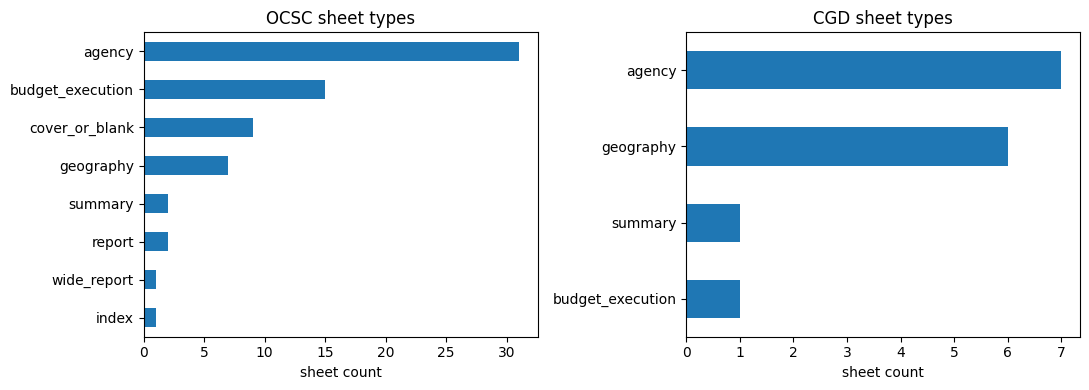

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, frame, title in [
    (axes[0], ocsc_sheets, "OCSC sheet types"),
    (axes[1], cgd_sheets, "CGD sheet types"),
]:
    counts = frame["sheet_type"].value_counts().sort_values(ascending=True)
    counts.plot(kind="barh", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("sheet count")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 4. EDA Findings to Engineering Decisions

ตารางนี้สรุปว่า observation จาก EDA ถูกแปลงเป็น design/pipeline decision อย่างไร เพื่อให้เห็นว่า notebook ไม่ได้เป็นแค่การดูไฟล์ Excel แต่เป็นหลักฐานของการออกแบบ data warehouse และ pipeline


In [5]:
eda_decisions = pd.DataFrame(
    [
        {
            "finding": "workbook มี cover/index/report decoration",
            "pipeline_decision": "เก็บ raw.workbook_sheets และ raw.cells เพื่อ audit ก่อนทำ staging",
        },
        {
            "finding": "sheet มี header หลายแถวและ newline ในชื่อ column",
            "pipeline_decision": "normalize/flatten header ใน clean.py และ extractor",
        },
        {
            "finding": "CGD มีงบประจำ/งบลงทุน/รวม ในแนวกว้าง",
            "pipeline_decision": "unpivot เป็น expense_category เพื่อให้ query ง่าย",
        },
        {
            "finding": "CGD มีทั้งมุมเบิกจ่ายและใช้จ่าย",
            "pipeline_decision": "แยกด้วย report_type เพื่อไม่ผสม metric คนละนิยาม",
        },
        {
            "finding": "OCSC มีหลายมิติกำลังพลใน workbook เดียว",
            "pipeline_decision": "ทำ fact แบบ metric-driven ด้วย metric_name และ metric_group",
        },
        {
            "finding": "OCSC-CGD ไม่มี agency code กลางครบทุก sheet",
            "pipeline_decision": "demo join ด้วย normalized Thai name; production ควรมี master agency mapping",
        },
    ]
)
display(eda_decisions)

cross_dataset_notes = pd.DataFrame(
    [
        {
            "topic": "agency/ministry name",
            "risk": "join แล้วหลุดหรือจับคู่ผิด",
            "current_handling": "normalize whitespace และ demo exact-name join",
        },
        {
            "topic": "time grain",
            "risk": "OCSC เป็น snapshot รายปี แต่ CGD เป็น as-of date",
            "current_handling": "เก็บ fiscal_year, fiscal_year_be และ as_of_date แยกกัน",
        },
        {
            "topic": "unit",
            "risk": "headcount เทียบกับ million baht โดยตรงไม่ได้",
            "current_handling": "แยก fact table และระบุ column unit ชัดเจน",
        },
        {
            "topic": "total/subtotal rows",
            "risk": "เกิด double count ใน query",
            "current_handling": "tag entity_type และให้ analyst filter ได้",
        },
    ]
)
display(cross_dataset_notes)


,finding,pipeline_decision
0,workbook มี cover/index/report decoration,เก็บ raw.workbook_sheets และ raw.cells เพื่อ audit ก่อนทำ staging
1,sheet มี header หลายแถวและ newline ในชื่อ column,normalize/flatten header ใน clean.py และ extractor
2,CGD มีงบประจำ/งบลงทุน/รวม ในแนวกว้าง,unpivot เป็น expense_category เพื่อให้ query ง่าย
3,CGD มีทั้งมุมเบิกจ่ายและใช้จ่าย,แยกด้วย report_type เพื่อไม่ผสม metric คนละนิยาม
4,OCSC มีหลายมิติกำลังพลใน workbook เดียว,ทำ fact แบบ metric-driven ด้วย metric_name และ metric_group
5,OCSC-CGD ไม่มี agency code กลางครบทุก sheet,demo join ด้วย normalized Thai name; production ควรมี master agency mapping


,topic,risk,current_handling
0,agency/ministry name,join แล้วหลุดหรือจับคู่ผิด,normalize whitespace และ demo exact-name join
1,time grain,OCSC เป็น snapshot รายปี แต่ CGD เป็น as-of date,"เก็บ fiscal_year, fiscal_year_be และ as_of_date แยกกัน"
2,unit,headcount เทียบกับ million baht โดยตรงไม่ได้,แยก fact table และระบุ column unit ชัดเจน
3,total/subtotal rows,เกิด double count ใน query,tag entity_type และให้ analyst filter ได้


## 5. OCSC EDA

OCSC เป็น workbook ที่ซับซ้อนกว่า เพราะมีหลาย report sections ในไฟล์เดียว ตารางด้านล่างแสดง sheet ที่ใหญ่ที่สุดและ sheet ที่มี merged/formula cells สูง


In [6]:
profile_cols = [
    "sheet_name",
    "max_row",
    "max_column",
    "non_empty_cells",
    "merged_cell_count",
    "formula_cell_count",
    "blank_row_count",
    "guessed_header_row",
    "sheet_type",
]

print("OCSC: top 12 sheets by non-empty cells")
display(ocsc_sheets.sort_values("non_empty_cells", ascending=False)[profile_cols].head(12))

print("OCSC: top 12 sheets by merged cells")
display(ocsc_sheets.sort_values("merged_cell_count", ascending=False)[profile_cols].head(12))


OCSC: top 12 sheets by non-empty cells


,sheet_name,max_row,max_column,non_empty_cells,merged_cell_count,formula_cell_count,blank_row_count,guessed_header_row,sheet_type
44,99-113,312,30,4933,10,16,0,10.0,budget_execution
42,88-97,199,39,4115,11,33,0,2.0,agency
23,55-64,203,18,2945,8,0,4,2.0,agency
9,17-29,648,15,2903,9,23,353,6.0,agency
49,124-127,103,44,2199,3,0,1,8.0,agency
21,50-53,135,25,1972,5,0,2,4.0,geography
50,128-133,104,38,1904,10,0,0,4.0,budget_execution
47,117-122,203,17,1757,5,0,5,5.0,agency
20,45-49,197,46,1389,20,0,95,9.0,geography
25,66-69,88,29,992,12,0,8,2.0,agency


OCSC: top 12 sheets by merged cells


,sheet_name,max_row,max_column,non_empty_cells,merged_cell_count,formula_cell_count,blank_row_count,guessed_header_row,sheet_type
26,70,33,30,218,79,0,4,8.0,wide_report
15,37,76,19,161,27,5,50,2.0,budget_execution
51,134,25,16,145,21,0,2,10.0,budget_execution
20,45-49,197,46,1389,20,0,95,9.0,geography
24,65,25,24,187,17,0,8,3.0,agency
19,43-44,83,40,243,16,7,38,2.0,agency
28,72,25,21,85,15,0,13,6.0,geography
25,66-69,88,29,992,12,0,8,2.0,agency
42,88-97,199,39,4115,11,33,0,2.0,agency
44,99-113,312,30,4933,10,16,0,10.0,budget_execution


In [7]:
ocsc_issues = pd.DataFrame(
    [
        {
            "observed_issue": "มี cover/index/report decoration",
            "why_it_matters": "ไม่ควร ingest ทุก sheet เป็น fact table เดียว",
            "cleaning_strategy": "เก็บ raw cells ทุก sheet แล้วเลือก normalize เฉพาะ sheet ที่ grain ชัดเจน",
        },
        {
            "observed_issue": "merged cells และ multi-row headers",
            "why_it_matters": "header ไม่อยู่ใน row เดียวและชื่อ metric กระจายหลาย column",
            "cleaning_strategy": "flatten header และ map metric เป็น long format",
        },
        {
            "observed_issue": "subtotal/total ปะปนกับ detail rows",
            "why_it_matters": "ถ้านับรวมกับ detail จะ double count",
            "cleaning_strategy": "tag `entity_type` เป็น total/ministry/agency",
        },
        {
            "observed_issue": "บาง cell เป็น formula/error token เช่น #REF!",
            "why_it_matters": "numeric conversion ต้องไม่ crash และต้อง audit ได้",
            "cleaning_strategy": "convert แบบ safe, เก็บ `source_value`, และใช้ DQ checks",
        },
    ]
)
ocsc_issues


,observed_issue,why_it_matters,cleaning_strategy
0,มี cover/index/report decoration,ไม่ควร ingest ทุก sheet เป็น fact table เดียว,เก็บ raw cells ทุก sheet แล้วเลือก normalize เฉพาะ sheet ที่ grain ชัดเจน
1,merged cells และ multi-row headers,header ไม่อยู่ใน row เดียวและชื่อ metric กระจายหลาย column,flatten header และ map metric เป็น long format
2,subtotal/total ปะปนกับ detail rows,ถ้านับรวมกับ detail จะ double count,tag `entity_type` เป็น total/ministry/agency
3,บาง cell เป็น formula/error token เช่น #REF!,numeric conversion ต้องไม่ crash และต้อง audit ได้,"convert แบบ safe, เก็บ `source_value`, และใช้ DQ checks"


In [8]:
def preview_sheet_by_name(path: Path, name_contains: str, rows: int = 12, cols: int = 12) -> pd.DataFrame:
    wb = load_workbook(path, data_only=True, read_only=True)
    ws = next(sheet for sheet in wb.worksheets if name_contains in sheet.title)
    values = []
    for row_idx in range(1, min(ws.max_row, rows) + 1):
        values.append(
            [
                str(ws.cell(row_idx, col_idx).value or "").replace("\n", " ")[:80]
                for col_idx in range(1, min(ws.max_column, cols) + 1)
            ]
        )
    wb.close()
    columns = [f"c{i}" for i in range(1, len(values[0]) + 1)]
    return pd.DataFrame(values, index=range(1, len(values) + 1), columns=columns)

print("OCSC preview: sheet '17-29' workforce by agency")
display(preview_sheet_by_name(OCSC_PATH, "17-29", rows=14, cols=12))

print("OCSC preview: sheet '88-97' workforce profile")
display(preview_sheet_by_name(OCSC_PATH, "88-97", rows=10, cols=20))


OCSC preview: sheet '17-29' workforce by agency


,c1,c2,c3,c4,c5,c6,c7,c8,c9,c10,c11,c12
1,ข้าราชการ ลูกจ้างประจำ ลูกจ้างชั่วคราว พนักงานราชการ และพนักงานจ้าง ปีงบประมาณ พ,,,,,,,,,,,
2,ส่วนราชการ,,,ข้าราชการ,ลูกจ้างประจำ,,ลูกจ้างชั่วคราว,,,พนักงานราชการ,พนักงานจ้าง,พนักงานมหาวิทยาลัย
3,,,,,เงินใน,เงินนอก,เงินใน,เงินใน,เงินนอก,,,เงินใน
4,,,,,งบประมาณ,งบประมาณ,งบประมาณ,งบประมาณ,งบประมาณ,,,งบประมาณ
5,,,,,(งบบุคลากร),,(งบบุคลากร),(งบอื่นๆ),,,,(งบเงินอุดหนุน)
6,รวม,,,1387895,64246,11644,51243,126969,84579,159437,223528,#REF!
7,1. สำนักนายกรัฐมนตรี,,,7025,330,,49,14,295,1763,,
8,,1.1,สำนักงานปลัดสำนักนายกรัฐมนตรี,364,18,,,,,221,,
9,,1.2,กรมประชาสัมพันธ์,1867,99,,,,290,502,,
10,,1.3,สำนักงานคณะกรรมการคุ้มครองผู้บริโภค,120,2,,,,,146,,


OCSC preview: sheet '88-97' workforce profile


,c1,c2,c3,c4,c5,c6,c7,c8,c9,c10,c11,c12,c13,c14,c15,c16,c17,c18,c19,c20
1,จำนวนข้าราชการพลเรือนสามัญ ปีงบประมาณ พ.ศ. 2567 จำแนกตามส่วนราชการ ช่วงอายุ เพศ,,,,,,,,,,,,,,,,,,,
2,ส่วนราชการ,รวม,ช่วงอายุ(ปี),,,,,,,,,,อายุเฉลี่ย,เพศ,,,ระดับการศึกษา,,,
3,,,<21,21-25,26-30,31-35,36-40,41-45,46-50,51-55,56-60,>60,,ชาย,หญิง,%หญิง,ต่ำกว่า ป.ตรี,ป.ตรี,ป.โท,ป.เอก
4,สำนักนายกรัฐมนตรี,7025,,104,767,978,1019,1143,1072,923,928,91,43.29010676156584,2782,4243,60.39857651245551,1400,2992,2505,128
5,สำนักงานปลัดสำนักนายกรัฐมนตรี,364,,,36,37,63,72,43,46,57,10,44.40659340659341,119,245,67.3076923076923,13,184,165,2
6,กรมประชาสัมพันธ์,1867,,8,111,196,268,323,267,332,337,25,45.770755222281736,966,901,48.259239421531866,716,855,288,8
7,สำนักงานคณะกรรมการคุ้มครองผู้บริโภค,120,,,2,8,20,30,32,18,7,3,45.25,51,69,57.49999999999999,3,60,53,4
8,สำนักเลขาธิการนายกรัฐมนตรี,288,,4,30,35,33,55,42,36,47,6,44.322916666666664,101,187,64.93055555555556,38,126,119,5
9,สำนักเลขาธิการคณะรัฐมนตรี,235,,8,38,28,20,27,46,32,36,,43.2,79,156,66.38297872340425,59,114,60,2
10,สำนักข่าวกรองแห่งชาติ,758,,3,43,119,104,94,160,111,113,11,44.87335092348285,352,406,53.562005277044854,226,368,163,1


## 6. CGD EDA

CGD โครงสร้างค่อนข้างสม่ำเสมอ แต่ต้องอ่านความหมายทางธุรกิจให้ถูก: `เบิกจ่าย` และ `ใช้จ่าย` ไม่ใช่ metric เดียวกัน


In [9]:
print("CGD: all sheets")
display(cgd_sheets[profile_cols].sort_values("sheet_name"))

cgd_issues = pd.DataFrame(
    [
        {
            "observed_issue": "หัวตาราง 2 ชั้น",
            "why_it_matters": "ชื่อ measure เช่น budget/disbursement/pct อยู่คนละ row กับ current/investment/total",
            "cleaning_strategy": "หา group span จาก header row แล้ว unpivot เป็น long rows",
        },
        {
            "observed_issue": "มีทั้ง sheet เบิกจ่ายและใช้จ่าย",
            "why_it_matters": "เบิกจ่ายคือเงินจ่ายจริง ส่วนใช้จ่ายรวมมุมมอง commitment/PO บางส่วน",
            "cleaning_strategy": "เก็บ `report_type` เป็น disbursement/expenditure",
        },
        {
            "observed_issue": "หน่วยเงินเป็นล้านบาท",
            "why_it_matters": "ต้องระบุ unit ชัดเจนเพื่อไม่ให้ analyst ตีความผิด",
            "cleaning_strategy": "ใช้ column suffix `_million_baht`",
        },
        {
            "observed_issue": "ชื่อหน่วยงานอาจซ้ำ แต่มี entity_code ต่างกัน",
            "why_it_matters": "duplicate check ต้องใช้ grain ที่รวม code ไม่ใช่ใช้ชื่ออย่างเดียว",
            "cleaning_strategy": "grain ของ CGD ใช้ source/sheet/entity/entity_code/report_type/expense_category",
        },
    ]
)
cgd_issues


CGD: all sheets


,sheet_name,max_row,max_column,non_empty_cells,merged_cell_count,formula_cell_count,blank_row_count,guessed_header_row,sheet_type
0,1.สรุปภาพรวม,21,16,77,10,19,0,9,summary
9,10.รัฐวิสาหกิจ,33,12,297,14,0,1,4,agency
10,11.จังหวัดได้รับจัดสรร,105,15,1449,14,0,1,4,geography
11,12.จังหวัดได้รับจัดสรร(ใช้จ่าย),109,18,1453,112,0,1,4,geography
12,13.ส่วนกลางจัดสรรให้จังหวัด,88,15,1179,14,0,2,6,geography
13,14.ส่วนกลางจัดสรรให้จังหวัด(ใช้,91,18,1183,94,0,1,5,geography
14,15.กองทุนฯ,46,12,453,14,0,1,4,budget_execution
1,2.กระทรวง,37,22,558,41,0,1,4,agency
2,3.หน่วยงาน,323,15,4719,14,0,1,4,agency
3,4.หน่วยงาน(ใช้จ่าย),327,18,4723,330,0,1,4,agency


,observed_issue,why_it_matters,cleaning_strategy
0,หัวตาราง 2 ชั้น,ชื่อ measure เช่น budget/disbursement/pct อยู่คนละ row กับ current/investment/total,หา group span จาก header row แล้ว unpivot เป็น long rows
1,มีทั้ง sheet เบิกจ่ายและใช้จ่าย,เบิกจ่ายคือเงินจ่ายจริง ส่วนใช้จ่ายรวมมุมมอง commitment/PO บางส่วน,เก็บ `report_type` เป็น disbursement/expenditure
2,หน่วยเงินเป็นล้านบาท,ต้องระบุ unit ชัดเจนเพื่อไม่ให้ analyst ตีความผิด,ใช้ column suffix `_million_baht`
3,ชื่อหน่วยงานอาจซ้ำ แต่มี entity_code ต่างกัน,duplicate check ต้องใช้ grain ที่รวม code ไม่ใช่ใช้ชื่ออย่างเดียว,grain ของ CGD ใช้ source/sheet/entity/entity_code/report_type/expense_category


In [10]:
print("CGD preview: summary sheet")
display(preview_sheet_by_name(CGD_PATH, "สรุปภาพรวม", rows=12, cols=10))

print("CGD preview: disbursement by agency")
display(preview_sheet_by_name(CGD_PATH, "3.", rows=12, cols=15))

print("CGD preview: expenditure by agency")
display(preview_sheet_by_name(CGD_PATH, "4.", rows=12, cols=18))


CGD preview: summary sheet


,c1,c2,c3,c4,c5,c6,c7,c8,c9,c10
1,รายงานผลการเบิกจ่ายงบประมาณ ประจำปีงบประมาณ พ.ศ. 2569,,,,,,,,,
2,ตั้งแต่ต้นปีงบประมาณ จนถึง ณ วันที่ 3 กรกฎาคม 2569,,,,,,,,,
3,,,,,,,,หน่วย : ล้านบาท,,
4,รายการ,วงเงินงบประมาณ หลังโอนเปลี่ยนแปลง,จัดสรร,การใช้จ่าย,,เบิกจ่าย,,คงเหลือยังไม่เบิกจ่าย,,
5,,,,จำนวนเงิน,ร้อยละ,จำนวนเงิน,ร้อยละ,จำนวนเงิน,ร้อยละ,
6,1. งบประมาณรายจ่าย ประจำปีงบประมาณ พ.ศ. 2569,3780600,3741220.88,3155044.61,83.45354203036555,2940281.46,77.77287890810982,840318.54,22.227121091890176,
7,1.1 รายจ่ายประจำ,2976554.54,2974818.01,2537948.52,85.26464023736652,2522927.96,84.76001115034163,453626.59,15.239989185617274,
8,1.2 รายจ่ายลงทุน,804045.46,766402.87,617096.09,76.74890546611631,417353.5,51.91,386691.95,48.09329437666373,
9,รายจ่ายลงทุนกรณีไม่รวมงบกลาง,774280.46,762666.18,614438.26,79.35603334223364,416218.09,53.7554686579589,358062.37,46.2445313420411,
10,2. เงินกันไว้เบิกเหลื่อมปี,320696.39,,293797.45,91.6123346446151,234975.7,73.27045371480483,85720.69,26.729546285195163,


CGD preview: disbursement by agency


,c1,c2,c3,c4,c5,c6,c7,c8,c9,c10,c11,c12,c13,c14,c15
1,รายงานผลการเบิกจ่ายเงินงบประมาณประจำปี พ.ศ. 2569 จำแนกตามหน่วยงาน เรียงลำดับผลกา,,,,,,,,,,,,,,
2,ตั้งแต่ต้นปีงบประมาณ จนถึงวันที่ 3 กรกฎาคม 2569,,,,,,,,,,,,,,
3,หน่วย: ล้านบาท,,,,,,,,,,,,,,
4,ลำดับ ที่,หน่วยงาน,รายจ่ายประจำ,,,,รายจ่ายลงทุน,,,,รวม,,,,รหัสกรม
5,,,วงเงิน งบประมาณ หลังโอน เปลี่ยนแปลง,PO+สำรอง เงินมีหนี้,เบิกจ่าย,ร้อยละเบิกจ่าย ต่องบประมาณ หลังโอน เปลี่ยนแปลง,วงเงิน งบประมาณ หลังโอน เปลี่ยนแปลง,PO+สำรอง เงินมีหนี้,เบิกจ่าย,ร้อยละเบิกจ่าย ต่องบประมาณ หลังโอน เปลี่ยนแปลง,วงเงิน งบประมาณ หลังโอน เปลี่ยนแปลง,PO+สำรอง เงินมีหนี้,เบิกจ่าย,ร้อยละเบิกจ่าย ต่องบประมาณ หลังโอน เปลี่ยนแปลง,
6,1,สำนักงานคณะกรรมการดิจิทัลเพื่อเศรษฐกิจและสังคมแห่งชาติ,196.10418,71.42466,97.04162189,49.4847289282666,2661.03232,2573.65365618,59.93251582,2.2522280308117417,2857.1365,2645.07831618,156.97413771,5.494107044238174,11009
7,2,กรมท่าอากาศยาน,607.59595549,14.45500047,429.54215307,70.69536082141836,4663.25074451,2223.75549307,555.88935603,11.920640482059499,5270.8467,2238.21049354,985.4315091,18.695886357309536,08009
8,3,กรมโยธาธิการและผังเมือง,1543.313603,9.32941224,1189.04166916,77.04472162032773,40580.700397,21376.70271736,9788.18920724,24.120306232968836,42124.014,21386.0321296,10977.2308764,26.059318270096483,15007
9,4,สำนักงานเศรษฐกิจการคลัง,1854.55462,335.77374308,448.11886735,24.163152840976988,211.03398,48.75824866,157.40522801,74.5876223393029,2065.5886,384.53199174,605.52409536,29.314844948311585,03011
10,5,สำนักงานปลัดกระทรวงคมนาคม,453.2638,65.97065015,304.69228241,67.22184352908836,611.7223,57.15710336,18.88917113,3.087867015801124,1064.9861,123.12775351,323.58145354,30.383631630497337,08002


CGD preview: expenditure by agency


,c1,c2,c3,c4,c5,c6,c7,c8,c9,c10,c11,c12,c13,c14,c15,c16,c17,c18
1,รายงานผลการใช้จ่ายเงินงบประมาณประจำปี พ.ศ. 2569 จำแนกตามหน่วยงาน เรียงลำดับผลการ,,,,,,,,,,,,,,,,,
2,ตั้งแต่ต้นปีงบประมาณ จนถึงวันที่ 3 กรกฎาคม 2569,,,,,,,,,,,,,,,,,
3,หน่วย: ล้านบาท,,,,,,,,,,,,,,,,,
4,ลำดับ ที่,หน่วยงาน,,,รายจ่ายประจำ,,,,รายจ่ายลงทุน,,,,รวม,,,,รหัสกรม,
5,,,,,วงเงิน งบประมาณ หลังโอน เปลี่ยนแปลง,การใช้จ่าย,ร้อยละการใช้จ่าย ต่องบประมาณ หลังโอน เปลี่ยนแปลง,สูง/ต่ำกว่า เป้าหมายการ ใช้จ่าย รายเดือน,วงเงิน งบประมาณ หลังโอน เปลี่ยนแปลง,การใช้จ่าย,ร้อยละการใช้จ่าย ต่องบประมาณ หลังโอน เปลี่ยนแปลง,สูง/ต่ำกว่า เป้าหมายการ ใช้จ่าย รายเดือน,วงเงิน งบประมาณ หลังโอน เปลี่ยนแปลง,การใช้จ่าย,ร้อยละการใช้จ่าย ต่องบประมาณ หลังโอน เปลี่ยนแปลง,สูง/ต่ำกว่า เป้าหมายการ ใช้จ่าย รายเดือน,,
6,1,สำนักงานขับเคลื่อนการปฏิรูปประเทศ ยุทธศาสตร์ชาติ และการสร้างความสามัคคีปรองดอง,,,79.6259,33.97705265,42.67085540006455,-46.32914459993545,6.0442,1.52995392,25.31276132490652,-53.687238675093475,85.6701,35.50700657,41.44620651779326,-45.55379348220674,01041,
7,2,สำนักงานปลัดกระทรวงคมนาคม,,,453.2638,370.66293256,81.77642524287181,-7.223574757128189,611.7223,76.04627449,12.431502740704401,-66.5684972592956,1064.9861,446.70920705,41.945073935706766,-45.054926064293234,08002,
8,3,กรมการข้าว,,,2164.65961888,1581.1424347,73.04346701483196,-15.95653298516804,2269.25238112,516.33923405,22.753715644231622,-56.24628435576838,4433.912,2097.48166875,47.305441983287,-39.694558016713,07018,
9,4,สำนักงานนโยบายและแผนทรัพยากรธรรมชาติและสิ่งแวดล้อม,,,363.1441561,306.51811982,84.40673343386896,-4.593266566131036,763.0782439,229.8991418,30.12785957898806,-48.87214042101194,1126.2224,536.41726162,47.629780904730715,-39.370219095269285,09011,
10,5,เมืองพัทยา,,,1048.9409,947.5183,90.33095191540343,1.3309519154034322,1354.0176,199.64619946,14.744727059677807,-64.2552729403222,2402.9585,1147.16449946,47.73967171967389,-39.26032828032611,75003,


## 7. Extracted Rows and Transform Validation

ส่วนนี้เรียก extractor จริงจาก pipeline เพื่อให้เห็นว่า EDA เชื่อมกับ implementation ไม่ใช่แค่การดู Excel ด้วยตา


In [11]:
run_id = "notebook-eda"
ocsc_meta = SourceFileMetadata(
    dataset_name="ocsc_government_manpower",
    source_name="OCSC government workforce statistics",
    path=OCSC_PATH,
    sha256=sha256_file(OCSC_PATH),
    fiscal_year=2024,
    fiscal_year_be=2567,
)
cgd_meta = SourceFileMetadata(
    dataset_name="cgd_budget_execution",
    source_name="CGD budget disbursement statistics",
    path=CGD_PATH,
    sha256=sha256_file(CGD_PATH),
    fiscal_year=2026,
    fiscal_year_be=2569,
)

ocsc_extract = extract_ocsc_workbook(OCSC_PATH, ocsc_meta, run_id)
cgd_extract = extract_cgd_workbook(CGD_PATH, cgd_meta, run_id)
ocsc_workforce = pd.concat(
    [ocsc_extract.workforce_agency, ocsc_extract.workforce_profile],
    ignore_index=True,
)

extracted_summary = pd.DataFrame(
    [
        {
            "dataset": "OCSC",
            "raw_cell_rows": len(ocsc_extract.raw_cells),
            "normalized_rows": len(ocsc_workforce),
            "target_table": "staging.ocsc_workforce",
        },
        {
            "dataset": "CGD",
            "raw_cell_rows": len(cgd_extract.raw_cells),
            "normalized_rows": len(cgd_extract.budget_execution),
            "target_table": "staging.cgd_budget_execution",
        },
    ]
)
extracted_summary


C:\Users\Admin\AppData\Local\Temp\ipykernel_12532\1205571002.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  ocsc_workforce = pd.concat(


,dataset,raw_cell_rows,normalized_rows,target_table
0,OCSC,32653,5801,staging.ocsc_workforce
1,CGD,93237,2913,staging.cgd_budget_execution


In [12]:
print("OCSC extracted rows by metric group")
display(
    ocsc_workforce.groupby(["entity_type", "metric_group"], dropna=False)
    .size()
    .reset_index(name="rows")
    .sort_values("rows", ascending=False)
    .head(20)
)

print("CGD extracted rows by report type, entity type, and expense category")
display(
    cgd_extract.budget_execution.groupby(
        ["report_type", "entity_type", "expense_category"], dropna=False
    )
    .size()
    .reset_index(name="rows")
    .sort_values(["report_type", "entity_type", "expense_category"])
)


OCSC extracted rows by metric group


,entity_type,metric_group,rows
0,agency,age,1911
2,agency,employment_type,1897
1,agency,education_level,696
3,agency,gender,522
5,ministry,age,209
7,ministry,employment_type,196
4,agency,total,174
6,ministry,education_level,76
8,ministry,gender,57
10,total,age,21


CGD extracted rows by report type, entity type, and expense category


,report_type,entity_type,expense_category,rows
0,disbursement,agency,current,312
1,disbursement,agency,investment,312
2,disbursement,agency,total,312
3,disbursement,fund,current,35
4,disbursement,fund,investment,35
5,disbursement,fund,total,35
6,disbursement,ministry,current,24
7,disbursement,ministry,investment,24
8,disbursement,ministry,total,24
9,disbursement,province,current,170


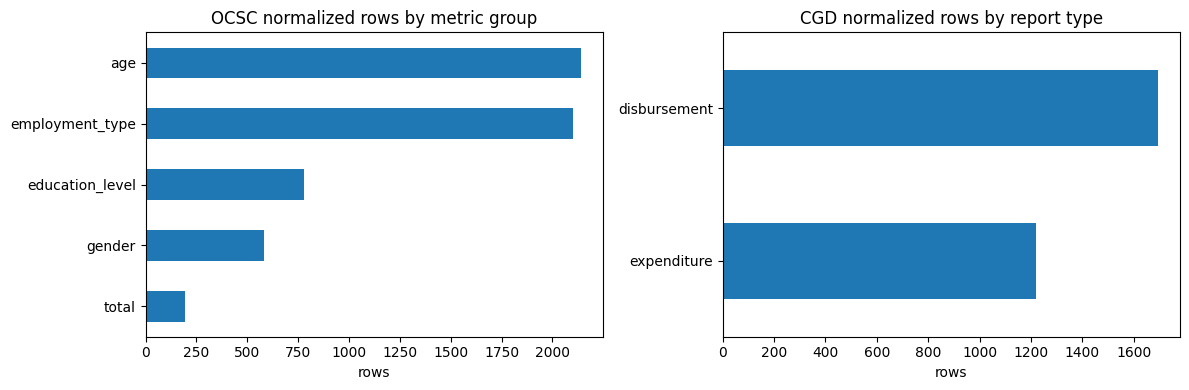

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ocsc_workforce["metric_group"].value_counts().sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("OCSC normalized rows by metric group")
axes[0].set_xlabel("rows")
axes[0].set_ylabel("")

cgd_extract.budget_execution["report_type"].value_counts().sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("CGD normalized rows by report type")
axes[1].set_xlabel("rows")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


## 8. Data Quality Checks

DQ checks ใช้กฎที่ตรงกับ business grain เช่น CGD ต้องรวม `entity_code` ใน duplicate key เพราะบางหน่วยงานชื่อซ้ำได้


In [14]:
dq_result = run_data_quality_checks(cgd_extract.budget_execution, ocsc_workforce, run_id)
dq_result


,ingestion_run_id,check_name,severity,dataset_name,table_name,issue_count,sample,status
0,notebook-eda,all_core_checks,info,all,all,0,"Core range, non-negative, and duplicate checks passed.",passed


## 9. Takeaways

- ทั้ง 2 datasets ถูกแยก source, extractor, staging และ mart ชัดเจน
- OCSC ต้องระวัง report workbook structure จึงใช้แนว raw-first และ normalize เฉพาะ grain ที่ชัดเจนก่อน
- CGD เหมาะกับการ flatten/unpivot เพราะ header structure ค่อนข้างซ้ำกันหลาย sheet
- การ join ระหว่าง OCSC และ CGD ยังควรถือเป็น demo จนกว่าจะมี master agency mapping
- Notebook นี้ควรใช้เป็น EDA evidence ส่วนการ demo pipeline ให้ใช้ CLI ใน README
